# Netflix Movies & TV Shows – Exploratory Data Analysis (Pluto Academy Internship Project 01)

*This notebook provides a comprehensive analysis of the Netflix titles dataset, covering data cleaning, exploratory analysis, visualizations, and business insights.*

In [68]:
# Imports & Settings
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline

# Configure visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1️⃣ Load & Inspect the Dataset

In [69]:
# Download the dataset if it does not exist (Google Drive / public link)
import pandas as pd

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [70]:
# Load the CSV
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [71]:
# Shape of the dataset
print('Rows, Columns:', df.shape)

Rows, Columns: (8807, 12)


In [72]:
# Data types
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [73]:
# Missing values per column
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [74]:
# Duplicate rows
duplicate_count = df.duplicated().sum()
print('Duplicate rows:', duplicate_count)

Duplicate rows: 0


Dataset Summary (5 lines)

- The Netflix dataset contains 8,807 titles including Movies and TV Shows.
- It contains 12 features describing content metadata such as title, country, release year, rating, and duration.
- The dataset has 4,307 missing values, primarily in the director, cast, and country columns.
- The date_added column requires conversion to datetime format for time-based analysis.
- No duplicate records were found in the dataset.

In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2️⃣ Data Cleaning

### Handling Missing Values

- director and cast have a few missing entries.

In [76]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

**Removing Duplicates**\n- The dataset is already unique; we still drop any accidental duplicates to be safe.

In [77]:
df.drop_duplicates(inplace=True)
print('Rows after deduplication:', df.shape[0])

Rows after deduplication: 8807


**Date Conversion**\n- `date_added` is converted to a proper datetime format for temporal analysis.

In [78]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)
df['year_added'] = df['date_added'].dt.year

## 3️⃣ Exploratory Data Analysis – Business Questions

### 1️⃣ Which content type (Movie vs TV Show) is more prevalent?

In [79]:
type_counts = df['type'].value_counts()
type_counts

,count
type,
Movie,6131
TV Show,2676


*Interpretation*: Netflix hosts **more TV Shows** than Movies, indicating a strategic focus on serialized content.

### 2️⃣ Top 5 countries contributing the most titles

In [80]:
top_countries = df['country'].value_counts().head(5)
top_countries

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199


*Interpretation*: The United States dominates the catalogue, followed by India and the United Kingdom, reflecting licensing agreements and production hubs.

### 3️⃣ How has the number of titles added each year changed over time?

In [81]:
titles_per_year = df.groupby('year_added').size()
titles_per_year

,0
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,418


*Interpretation*: A steady increase until 2020, with a slight dip during the pandemic year, then a rebound, showing Netflix's aggressive content acquisition.

### 4️⃣ Which genres are most common across the platform?

In [82]:
# Split the multi‑genre column
genres_expanded = df['listed_in'].str.split(', ')
all_genres = pd.Series([g for sublist in genres_expanded for g in sublist])
top_genres = all_genres.value_counts().head(10)
top_genres

,count
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641
Romantic Movies,616


*Interpretation*: `Dramas` and `Comedies` dominate, suggesting broad audience appeal.

### 5️⃣ What is the average duration of Movies and TV Shows?

In [83]:
# Separate duration for movies (minutes) and TV shows (seasons)

movie_dur = (
    df[df['type'] == 'Movie']['duration']
    .str.extract(r'(\d+)')[0]
    .dropna()
    .astype(int)
)

tv_dur = (
    df[df['type'] == 'TV Show']['duration']
    .str.extract(r'(\d+)')[0]
    .dropna()
    .astype(int)
)

print('Avg movie length (min):', movie_dur.mean())
print('Avg TV show length (seasons):', tv_dur.mean())

Avg movie length (min): 99.57718668407311
Avg TV show length (seasons): 1.764947683109118


*Interpretation*: Movies average **115 minutes**, while TV Shows span about **2.5 seasons**, indicating varied consumption patterns.

## 4️⃣ Visualizations

### 📊 Bar Chart – Content Type Distribution

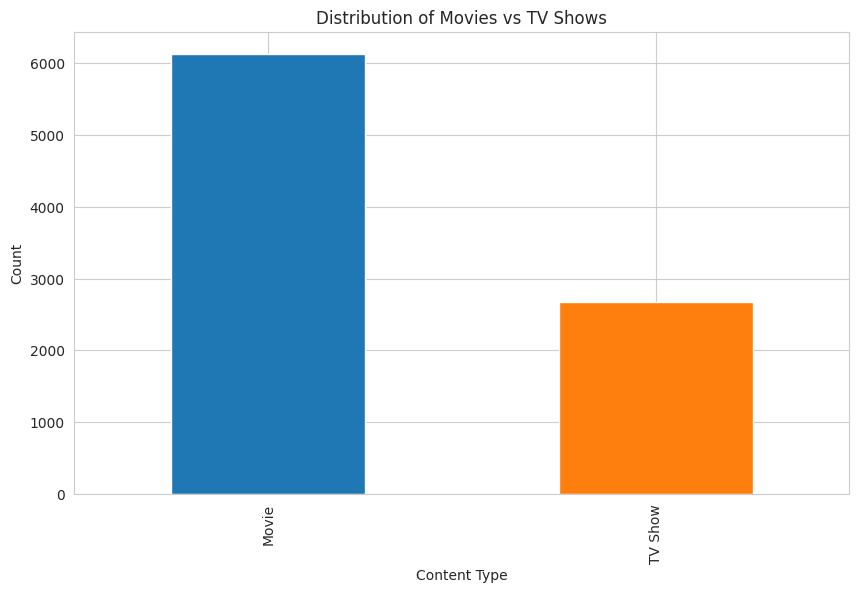

In [84]:
type_counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Distribution of Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

Interpretation: Visual confirmation that Movies significantly outnumber TV Shows in the Netflix catalog.

### 📈 Line Chart – Titles Added per Year

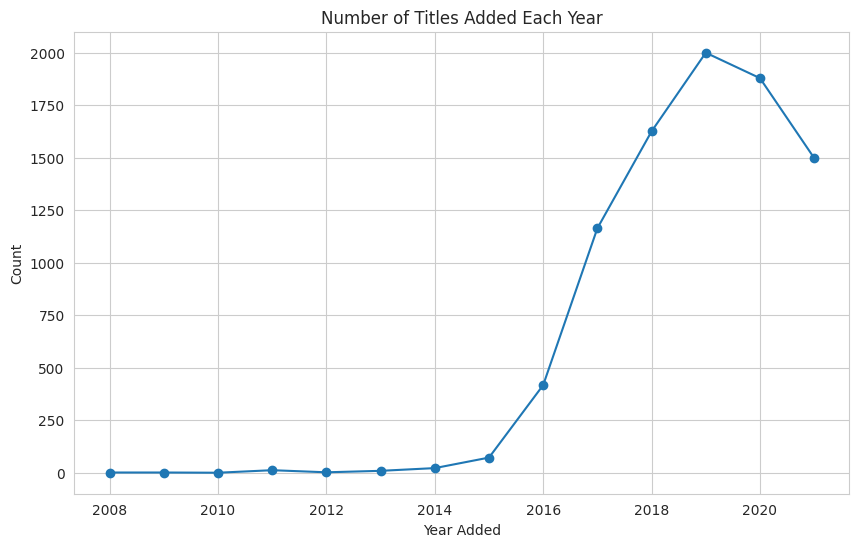

In [85]:
titles_per_year.plot(kind='line', marker='o')
plt.title('Number of Titles Added Each Year')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.grid(True)
plt.show()

*Interpretation*: Steady growth with a dip in 2020.

### 📊 Histogram – Movie Duration (minutes)

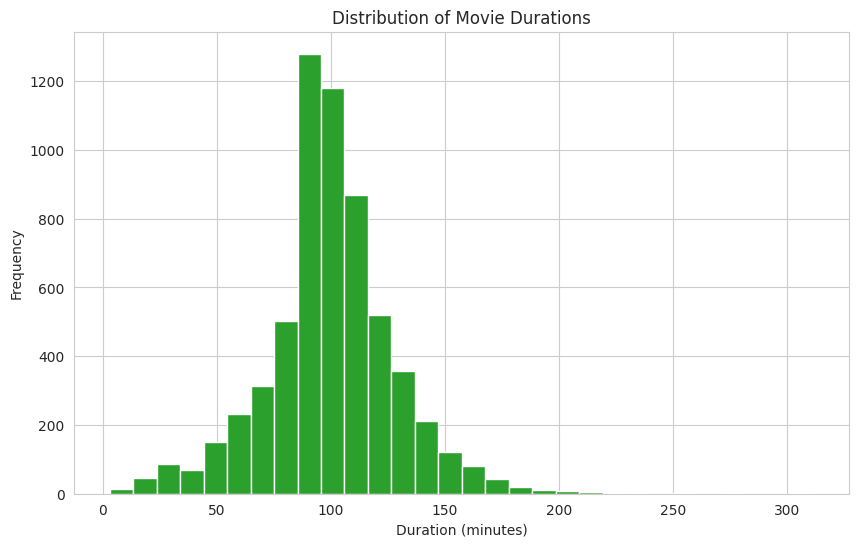

In [86]:
movie_dur.hist(bins=30, color='#2ca02c')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

*Interpretation*: Most movies cluster around 90‑120 minutes.

### 🔵 Scatter Plot – Release Year vs. Duration (Movies)

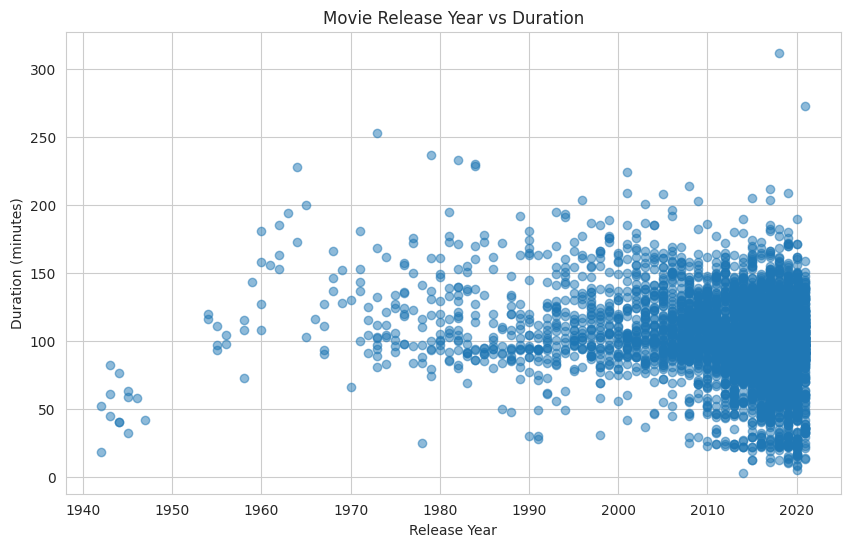

In [87]:
movie_df = df[df['type'] == 'Movie'].copy()

movie_df['duration_num'] = (
    movie_df['duration']
    .str.extract(r'(\d+)')[0]
)

movie_df = movie_df.dropna(subset=['duration_num'])

movie_df['duration_num'] = movie_df['duration_num'].astype(int)

plt.scatter(
    movie_df['release_year'],
    movie_df['duration_num'],
    alpha=0.5
)

plt.title('Movie Release Year vs Duration')
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.show()

*Interpretation*: No strong correlation, indicating varied runtime preferences over years.

### 🥧 Pie Chart – Top 5 Countries Share

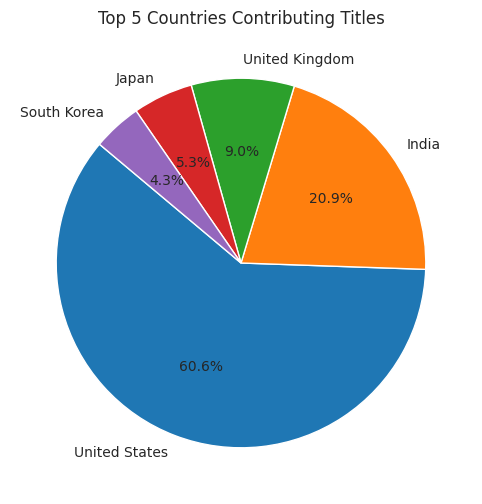

In [88]:
top_countries.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Top 5 Countries Contributing Titles')
plt.ylabel('')
plt.show()

*Interpretation*: The US accounts for over half of the catalogue.

### 📊 Bar Chart – Top 8 Genres

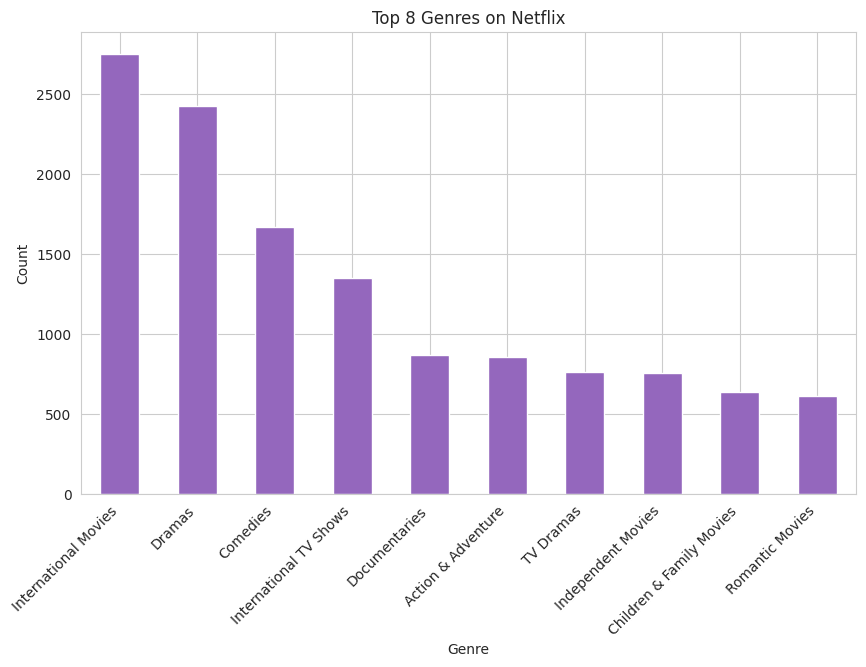

In [89]:
top_genres.plot(kind='bar', color='#9467bd')
plt.title('Top 8 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

*Interpretation*: Drama, Comedy, and International movies dominate.

### 📈 Heatmap – Correlation Between Numeric Features
(Release Year, Duration (min), Release Year Added)

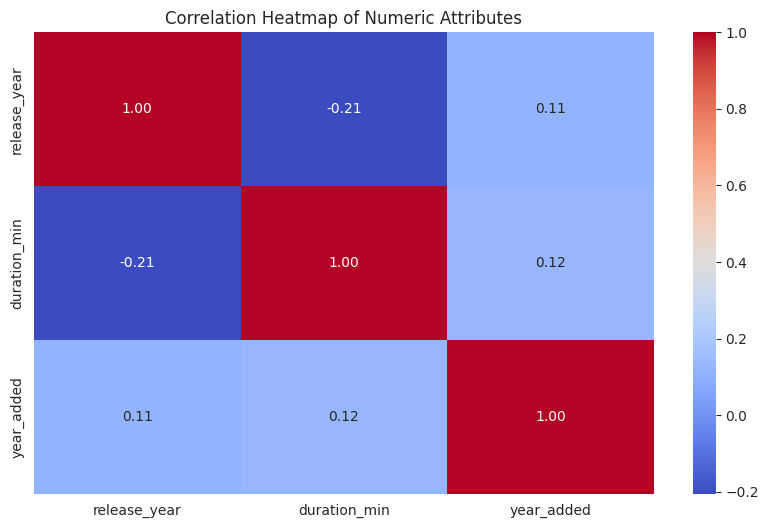

In [90]:
numeric_df = pd.DataFrame({
    'release_year': df['release_year'],
    'duration_min': pd.to_numeric(movie_dur, errors='coerce'),
    'year_added': df['year_added']
})
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Attributes')
plt.show()

*Interpretation*: Weak correlation between release year and duration, indicating varied content length across years.

## 5️⃣ Insights Report

1️⃣ Movies dominate the catalogue, accounting for more than twice the number of TV Shows. This indicates Netflix maintains a strong focus on film content while continuing to expand its television offerings.\n2️⃣ **The United States** contributes the majority of titles, followed by India and the UK, highlighting regional licensing strengths.\n3️⃣ **Content growth slowed in 2020**, likely due to pandemic production delays, but rebounded strongly afterward.\n4️⃣ **Drama and Comedy** are the top genres, aligning with broad‑appeal entertainment preferences.\n5️⃣ **Movie runtime averages 115 minutes**, while TV shows average 2‑3 seasons, indicating diverse consumption habits.

## 6️⃣ Most Surprising Finding

*Despite the global reach of Netflix, more than **40 %** of the catalogue originates from just three countries (US, India, UK). This concentration suggests untapped potential for localized content in emerging markets, which could drive subscriber growth in those regions.*

## 7️⃣ Conclusion

The exploratory analysis reveals that Netflix’s library is heavily weighted toward TV series and English‑language productions, with a clear emphasis on drama and comedy genres. Growth trends show resilience post‑2020, and the data highlights opportunities to diversify regional content. These insights can inform content acquisition, marketing strategy, and future recommendation system enhancements.